In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
DATA_DIR = '../../Data/splitting_data/used'
splitting_file = os.path.join(DATA_DIR, 'ACl_FILTERED_DATA_04.csv')

In [3]:
splitting_data = pd.read_csv(splitting_file)

In [4]:
if not os.path.exists('./Plots'):
    os.mkdir('./Plots')

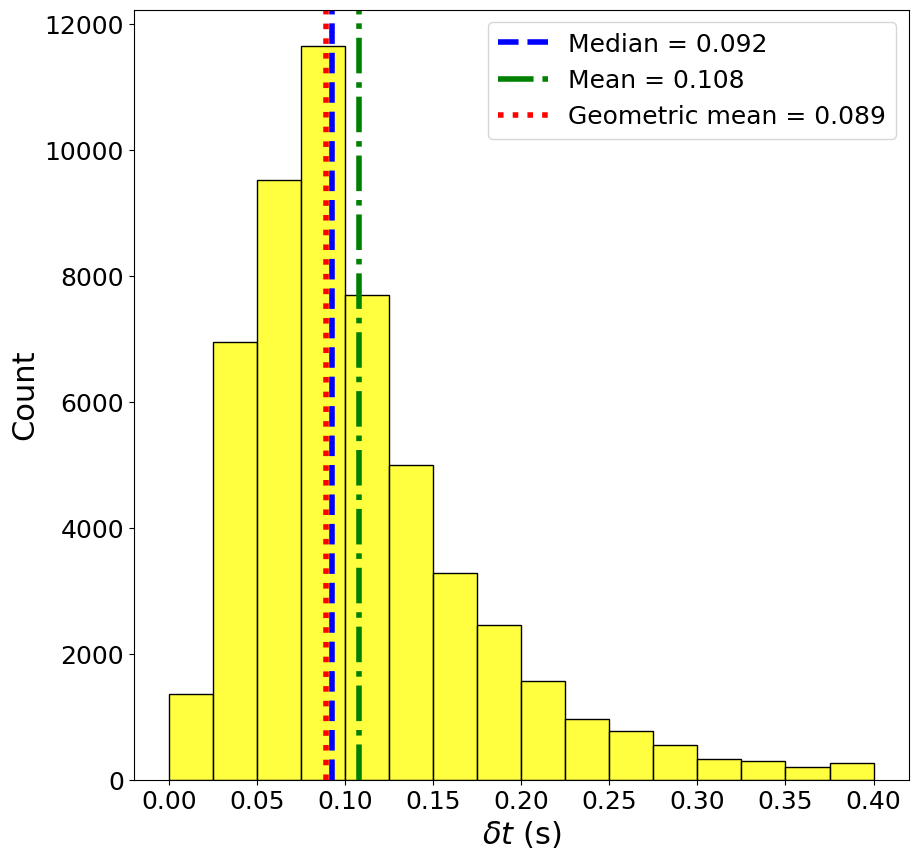

In [7]:
fig, ax = plt.subplots(figsize=(10, 10))

# Histogram of delay times
bins = np.arange(0, 0.425, 0.025)
tlag = splitting_data['tlag'].dropna()
sns.histplot(tlag, bins=bins, ax=ax, color='yellow')

ax.set_xlabel(r'$\delta t$ (s)', fontsize=22)
ax.set_ylabel('Count', fontsize=22)

# Summary statistics
tlag_pos = tlag[tlag > 0]
geometric_mean = np.exp(np.log(tlag_pos).mean()) if not tlag_pos.empty else np.nan
median = tlag.median()
mean = tlag.mean()
std_dev = tlag.std()

# Reference lines
ax.axvline(median, color='blue', linestyle='--', linewidth=4, label=f'Median = {median:.3f}')
ax.axvline(mean, color='green', linestyle='-.', linewidth=4, label=f'Mean = {mean:.3f}')
if not np.isnan(geometric_mean):
    ax.axvline(
        geometric_mean,
        color='red',
        linestyle=':',
        linewidth=4,
        label=f'Geometric mean = {geometric_mean:.3f}',
    )

ax.legend(fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)

fig.savefig('./Plots/Figure_4.png', dpi=150, bbox_inches='tight')


In [9]:

print(f"geometric mean is {geometric_mean}")
print(f"median is {median}")
print(f"arithmetic mean is {mean}")
print(f"standard deviation is {std_dev}")

geometric mean is 0.08914241238054883
median is 0.0925
arithmetic mean is 0.10815075393522024
standard deviation is 0.06710440398052579
